In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'seaborn'

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install seaborn

In [6]:
!python -m pip install seaborn

In [1]:
import seaborn as sns

In [2]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------- ----- 6.8/8.0 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 28.0 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ------- -------------------------------- 6.8/36.5 MB 41.6 MB/s eta 0:00:01
   --------- ------------------------------ 8.7/36.5 MB 20.9 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/36.5 MB 22.7 MB/s eta 0:00:01
   --------------------- ------------------ 19.9/36.5 MB 23.8 MB/s eta 0:00:01
   --------------------------- ------------ 25.4/36.5 MB 24.2 MB/s eta 0:00:01
   --------------------------------- ------ 30.7/36.5 MB 24.5 MB/s eta 0:00:01
   ---------------------------------------  36.2/36.5 MB 24.7 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.5 MB 24.7 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 20.5 MB/s  0:00:01

   

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
plt.figure(figsize=(8,6))

corr = team_data[["goals", "shots", "goals_conceded"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Team Performance Correlation Matrix")
plt.show()

NameError: name 'team_data' is not defined

<Figure size 800x600 with 0 Axes>

In [3]:
# Load datasets
shooting_for = pd.read_csv(r"../data/overwiev__stats_squads_shooting_for.csv")
standard_against = pd.read_csv(r"../data/overwiev__stats_squads_standard_against.csv")

# Clean team names
shooting_for["Squad"] = shooting_for["Squad"].str.strip()
standard_against["Squad"] = (
    standard_against["Squad"]
    .str.strip()
    .str.replace("vs ", "", regex=False)
)

# Rename columns
shooting_for = shooting_for.rename(columns={
    "Squad": "team",
    "Standard_Gls": "goals",
    "Standard_Sh": "shots"
})

standard_against = standard_against.rename(columns={
    "Squad": "team",
    "Performance_Gls": "goals_conceded"
})

# Merge
team_data = shooting_for.merge(
    standard_against[["team", "goals_conceded"]],
    on="team"
)

team_data.head()

,team,# Pl,90s,goals,shots,Standard_SoT,Standard_SoT%,Standard_Sh/90,Standard_SoT/90,Standard_G/Sh,Standard_G/SoT,Standard_PK,Standard_PKatt,goals_conceded
0,Arsenal,25,38.0,67,544,178,32.7,14.32,4.68,0.12,0.37,2,2,34
1,Aston Villa,28,38.0,56,478,159,33.3,12.58,4.18,0.11,0.33,3,6,51
2,Bournemouth,29,38.0,57,574,192,33.4,15.11,5.05,0.09,0.27,6,7,46
3,Brentford,28,38.0,65,434,173,39.9,11.42,4.55,0.14,0.35,5,6,54
4,Brighton,32,38.0,64,526,183,34.8,13.84,4.82,0.11,0.31,7,7,57


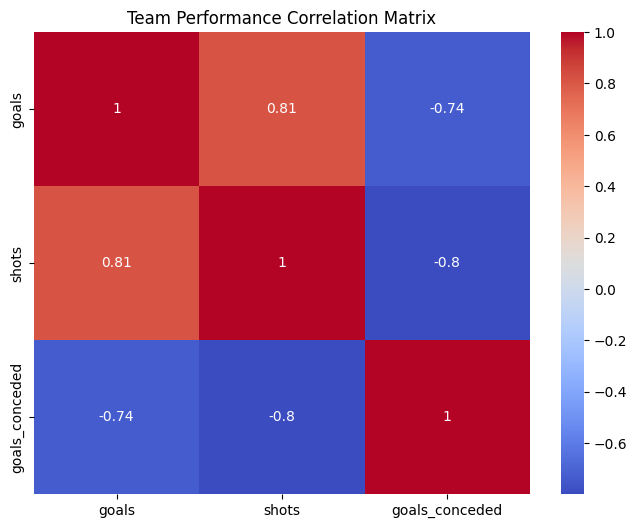

In [4]:
plt.figure(figsize=(8,6))

corr = team_data[["goals", "shots", "goals_conceded"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Team Performance Correlation Matrix")
plt.show()

In [5]:
X = team_data[["shots"]]
y = team_data["goals"]

model = LinearRegression()
model.fit(X, y)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.14064281124518765
Intercept: -14.582916871587393


In [6]:
features = team_data[["goals", "goals_conceded"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
team_data["cluster"] = kmeans.fit_predict(scaled)

team_data[["team", "goals", "goals_conceded", "cluster"]]

,team,goals,goals_conceded,cluster
0,Arsenal,67,34,1
1,Aston Villa,56,51,1
2,Bournemouth,57,46,1
3,Brentford,65,54,1
4,Brighton,64,57,1
5,Chelsea,61,43,1
6,Crystal Palace,49,48,0
7,Everton,39,44,0
8,Fulham,53,52,0
9,Ipswich Town,35,80,2


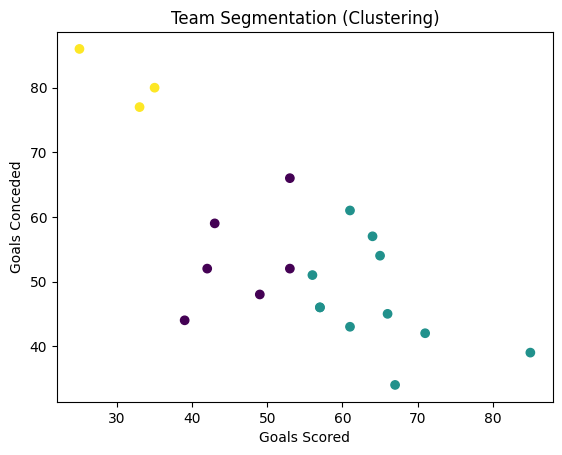

In [7]:
plt.figure()

plt.scatter(
    team_data["goals"],
    team_data["goals_conceded"],
    c=team_data["cluster"]
)

plt.xlabel("Goals Scored")
plt.ylabel("Goals Conceded")
plt.title("Team Segmentation (Clustering)")
plt.show()

In [8]:
team_data["cluster"].value_counts()

cluster
1    11
0     6
2     3
Name: count, dtype: int64

In [9]:
team_data.groupby("cluster")[["goals", "goals_conceded"]].mean()

,goals,goals_conceded
cluster,,
0,46.500000,53.500000
1,64.545455,47.090909
2,31.000000,81.000000
